# Notebook 04 — NDVI Analysis

**What you will learn:**
- xarray's computation model: operations stay lazy until forced
- How `.where()` works vs NumPy boolean indexing
- Dimension reduction with `.mean()` and `.idxmax()`
- The difference between `isel()` (integer) and `sel()` (label) indexing

---

## Background: NDVI

The Normalised Difference Vegetation Index measures live green vegetation density:

```
NDVI = (NIR - Red) / (NIR + Red)
```

- **NDVI > 0.5**: dense vegetation (forest, crops at peak growth)
- **NDVI 0.2–0.5**: sparse vegetation, grassland
- **NDVI < 0.1**: bare soil, water, urban

Healthy plants absorb red light (photosynthesis) and strongly reflect NIR — so the ratio goes up. The formula produces values in `[-1, 1]`.

In [1]:
import sys
sys.path.insert(0, "..")

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

ZARR_LOCAL = "../data/sentinel2_local.zarr"

ds = xr.open_zarr(ZARR_LOCAL)
print(ds)
print("\nTime steps:")
for t in ds.time.values:
    print(" ", str(t)[:10])

<xarray.Dataset> Size: 144MB
Dimensions:      (time: 3, y: 2788, x: 2158)
Coordinates:
  * time         (time) datetime64[ns] 24B 2023-06-04T16:02:09.577000 ... 202...
  * x            (x) float64 17kB 4.355e+05 4.355e+05 ... 4.786e+05 4.786e+05
  * y            (y) float64 22kB 4.428e+06 4.428e+06 ... 4.372e+06 4.372e+06
Data variables:
    blue         (time, y, x) uint16 36MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    green        (time, y, x) uint16 36MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    nir          (time, y, x) uint16 36MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    red          (time, y, x) uint16 36MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    spatial_ref  int64 8B ...

Time steps:
  2023-06-04
  2023-06-04
  2023-08-13


## Compute NDVI

xarray arithmetic on DataArrays is lazy — writing the formula builds a new task graph without reading any data. The operation also **broadcasts** automatically across all time steps.

In [2]:
nir = ds["nir"].astype("float32")
red = ds["red"].astype("float32")

# Mask the denominator before dividing so nodata pixels (nir+red==0) produce
# NaN rather than triggering a divide-by-zero RuntimeWarning.
denom = (nir + red)
ndvi = (nir - red) / denom.where(denom > 0)

# Give it a meaningful name and assign as a new variable
ndvi.name = "ndvi"

import dask.array as da
print("ndvi type:", type(ndvi.data))
print("Is still lazy:", isinstance(ndvi.data, da.Array))
print("ndvi DataArray:", ndvi)

ndvi type: <class 'dask.array.core.Array'>
Is still lazy: True
ndvi DataArray: <xarray.DataArray 'ndvi' (time: 3, y: 2788, x: 2158)> Size: 72MB
dask.array<truediv, shape=(3, 2788, 2158), dtype=float32, chunksize=(1, 2048, 2048), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 24B 2023-06-04T16:02:09.577000 ... 2023-08...
  * x        (x) float64 17kB 4.355e+05 4.355e+05 ... 4.786e+05 4.786e+05
  * y        (y) float64 22kB 4.428e+06 4.428e+06 ... 4.372e+06 4.372e+06


## Mask invalid pixels with .where()

`.where(condition)` keeps values where `condition=True` and replaces the rest with `NaN`. It differs from NumPy boolean indexing:

| | NumPy `arr[mask]` | xarray `.where(mask)` |
|-|---|----|  
| Output shape | Flat 1-D array (shape changes) | Same shape, invalid → NaN |
| Preserves dims/coords | No | Yes |
| Lazy | No | Yes |

In [3]:
# Mask: keep only physically valid NDVI values
ndvi_masked = ndvi.where(ndvi >= -1.0).where(ndvi <= 1.0)

# Also mask pixels where both bands are zero (no-data regions)
valid_data = (red > 0) | (nir > 0)
ndvi_masked = ndvi_masked.where(valid_data)

print("ndvi_masked still lazy:", isinstance(ndvi_masked.data, da.Array))
print("Shape unchanged:", ndvi_masked.shape, "==", ndvi.shape)

ndvi_masked still lazy: True
Shape unchanged: (3, 2788, 2158) == (3, 2788, 2158)


## Spatial mean time series

`.mean(dim=["x", "y"])` reduces the two spatial dimensions, leaving a 1-D array over `time`. This collapses millions of pixels per scene into one mean value per date.

Shape after reduction: (3,)
Remaining dims: ['time']

NDVI mean per date:
  2023-06-04: 0.5615
  2023-06-04: 0.4909
  2023-08-13: 0.5247


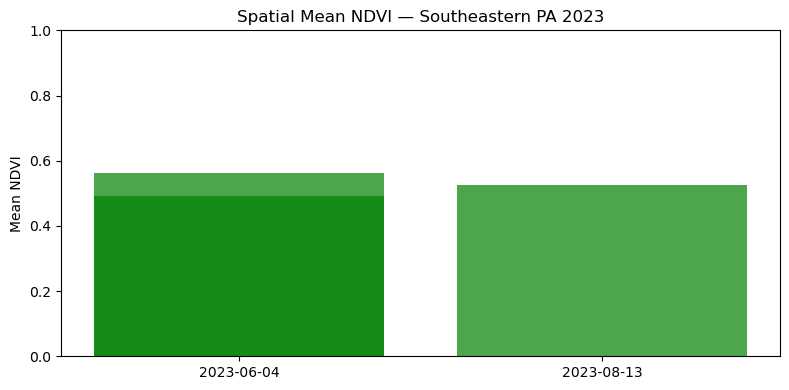

In [4]:
# skipna=True ignores NaN (masked) pixels in the mean
ndvi_mean = ndvi_masked.mean(dim=["x", "y"], skipna=True)

print("Shape after reduction:", ndvi_mean.shape)  # (time,)
print("Remaining dims:", list(ndvi_mean.dims))

# Now compute — this reads all pixel data and averages it
ndvi_mean_computed = ndvi_mean.compute()

print("\nNDVI mean per date:")
for t, v in zip(ndvi_mean_computed.time.values, ndvi_mean_computed.values):
    print(f"  {str(t)[:10]}: {v:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
dates = [str(t)[:10] for t in ndvi_mean_computed.time.values]
ax.bar(dates, ndvi_mean_computed.values, color="green", alpha=0.7)
ax.set_ylabel("Mean NDVI")
ax.set_title("Spatial Mean NDVI — Southeastern PA 2023")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## Find the date of maximum NDVI

`.idxmax(dim="time")` returns the coordinate value (a datetime) where the maximum occurs — not the integer index.

In [5]:
peak_date = ndvi_mean_computed.idxmax(dim="time").values
print("Date of peak NDVI:", str(peak_date)[:10])

# isel vs sel:
# isel(time=0)        — select by INTEGER position (like numpy [0])
# sel(time=peak_date) — select by LABEL value (the actual datetime)
ndvi_peak = ndvi_masked.sel(time=peak_date)
print("Shape of peak scene:", ndvi_peak.shape)

Date of peak NDVI: 2023-06-04
Shape of peak scene: (2788, 2158)


## Plot the NDVI map for the peak date

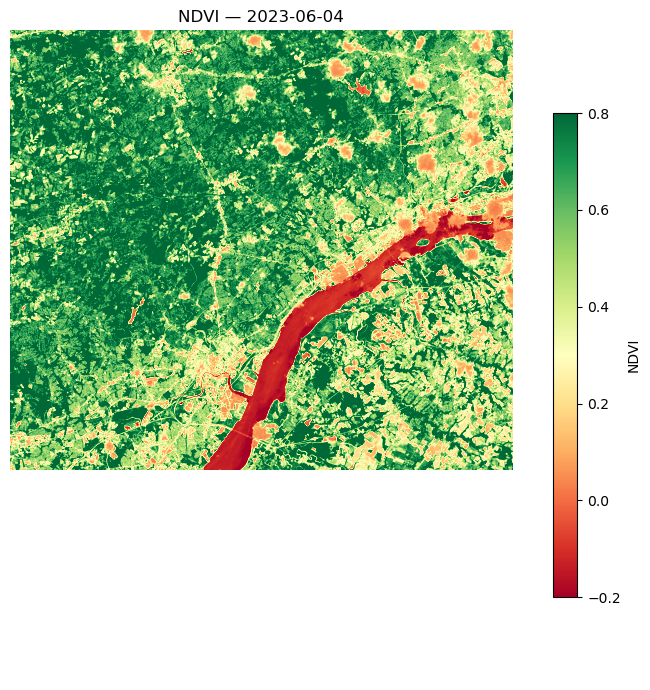

In [6]:
ndvi_peak_vals = ndvi_peak.compute().values

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(
    ndvi_peak_vals,
    cmap="RdYlGn",
    vmin=-0.2,
    vmax=0.8,
    origin="upper",
)
plt.colorbar(im, ax=ax, label="NDVI", fraction=0.03)
ax.set_title(f"NDVI — {str(peak_date)[:10]}")
ax.axis("off")
plt.tight_layout()
plt.show()

## Save enriched Dataset back to Zarr

We add `ndvi` as a new variable and save the enriched Dataset. Later notebooks (rioxarray, GeoZarr) will read from this store.

In [ ]:
import rioxarray  # noqa — registers .rio accessor

# Build enriched Dataset: original bands + ndvi
ds_enriched = ds.assign(ndvi=ndvi_masked.astype("float32"))

# Write the CRS into the dataset attributes so downstream notebooks
# (06_rioxarray, 07_geozarr) don't open it with CRS: None.
ds_enriched = ds_enriched.rio.write_crs("EPSG:32618")

print("Enriched dataset variables:", list(ds_enriched.data_vars))
print("CRS:", ds_enriched.rio.crs)

ZARR_ENRICHED = "../data/sentinel2_enriched.zarr"
print(f"\nWriting enriched dataset to {ZARR_ENRICHED} ...")
ds_enriched.to_zarr(ZARR_ENRICHED, mode="w")
print("Done.")

## Validation

In [8]:
import os
assert "ndvi" in ds_enriched.data_vars, "ndvi not in enriched dataset"

ndvi_check = ds_enriched["ndvi"].isel(time=0).compute().values
valid = ndvi_check[~np.isnan(ndvi_check)]
assert valid.min() >= -1.0 - 1e-5, f"NDVI below -1: {valid.min()}"
assert valid.max() <= 1.0 + 1e-5, f"NDVI above 1: {valid.max()}"

assert os.path.isdir(ZARR_ENRICHED), "Enriched zarr not written"
print("All assertions passed.")

All assertions passed.


---
## Learning Checkpoint — Q&A

**Q1:** When you write `(ds["nir"] - ds["red"]) / (ds["nir"] + ds["red"])`, does xarray compute anything immediately? Why not?

> *No — because both arrays are Dask-backed, xarray records the arithmetic as new nodes in the task graph. No S3 reads or arithmetic happen until `.compute()` or `.values` is called.*

**Q2:** What does `.where()` do in xarray — how is it different from NumPy boolean indexing?

> *`.where(cond)` keeps values where `cond=True` and replaces the rest with NaN, **preserving the original shape and all coordinates**. NumPy boolean indexing (`arr[mask]`) returns a flat 1-D array of the selected values, losing shape and label information.*

**Q3:** What does `mean(dim=["x","y"])` return — what are its remaining dimensions?

> *It returns a 1-D DataArray with only the `time` dimension — the two spatial dimensions have been averaged away. Shape goes from `(time, y, x)` to `(time,)`.*

**Q4:** What is the difference between `isel()` and `sel()`?

> *`isel()` selects by **integer position** (like NumPy `[0]`). `sel()` selects by **coordinate label** (the actual value — a datetime, a UTM coordinate, etc.). Use `sel()` when you know what value you want; use `isel()` when you know which position.*